# Problema 4 — Otimização mista da rede hidráulica

Este notebook apresenta a implementação do **Problema 4**, no qual existe um número limitado de canos grossos, de menor resistência hidráulica, e é necessário decidir em quais arestas da rede eles devem ser instalados.

A métrica otimizada é a maior pressão nodal da rede. Como a pressão de saída é prescrita, a menor pressão deixa de ser uma variável de projeto e passa a ser uma condição de contorno conhecida. Assim, o objetivo computacional é

\[
\min \; p^{\max}
\qquad \text{com} \qquad
p_i\leq p^{\max},\; i\in V.
\]

Nesta versão, **todos os estudos computacionais usam malhas retangulares**. A rede deixa de ser gerada aleatoriamente e passa a ser construída como uma grade de nós conectados horizontal e verticalmente.

A apresentação contém três estudos computacionais:

1. **Caso 1:** malha retangular `2 x 10`, com 20 nós, usada para mostrar a resolução por MILP;
2. **Caso 2:** malha retangular `10 x 10`, com 100 nós, usada para testar uma rede maior e estruturada;
3. **Caso 3:** mesma malha retangular do caso 2, mas com limite de tempo artificialmente muito baixo, mostrando que o código retorna a melhor solução viável encontrada ou uma solução heurística de fallback.


## 1. Importações

Para este notebook funcionar, os arquivos `Grid.py` e `ProblemaP4.py` devem estar dentro da pasta `src/` do projeto. A classe `GridP1` constrói a malha retangular e a versão corrigida da classe `ProblemaP4` minimiza diretamente a pressão máxima da rede.


In [1]:
from pathlib import Path
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display

try:
    import pandas as pd
except ImportError:
    pd = None

project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.Grid import GridP1
from src.ProblemaP4 import ProblemaP4


## 2. Funções auxiliares da apresentação

As funções abaixo reduzem repetição no notebook. Elas geram uma malha retangular, resolvem o P1 de referência, resolvem o P4 e exibem tabelas comparativas.


In [2]:
def gerar_malha_retangular(
    n_linhas,
    n_colunas,
    area=1.0,
    length=1.0,
    mu=1e-3,
    patm=0.0,
    Q_in=1.0,
    Q_out=None,
):
    p1 = GridP1(
        n=n_linhas,
        m=n_colunas,
        area=area,
        length=length,
        mu=mu,
        patm=patm,
        Q_in=Q_in,
        Q_out=Q_out,
    )
    p1.setup()
    p1.solve()
    return p1


def mostrar_resumo_p1(p1, nome):
    print(nome)
    print("numero de nos:", p1.num_nodes)
    print("numero de arestas:", p1.num_edges)
    print("pressao minima p1:", float(np.min(p1.p)), "Pa")
    print("pressao maxima p1:", float(np.max(p1.p)), "Pa")
    print("amplitude de pressao p1:", float(np.max(p1.p) - np.min(p1.p)), "Pa")


def calcular_numero_canos_grossos(num_edges, thick_pipe_fraction=0.10, rounding="ceil"):
    if num_edges <= 0:
        raise ValueError("num_edges deve ser positivo")

    if not 0 <= thick_pipe_fraction <= 1:
        raise ValueError("thick_pipe_fraction deve estar entre 0 e 1")

    raw_value = thick_pipe_fraction * num_edges

    if rounding == "ceil":
        n_thick = math.ceil(raw_value)
    elif rounding == "floor":
        n_thick = math.floor(raw_value)
    elif rounding == "round":
        n_thick = round(raw_value)
    else:
        raise ValueError("rounding deve ser 'ceil', 'floor' ou 'round'")

    if thick_pipe_fraction > 0:
        n_thick = max(1, n_thick)

    return min(int(n_thick), int(num_edges))


def resolver_caso_p4(
    p1,
    nome,
    time_limit,
    mip_rel_gap=1e-4,
    disp=False,
    thick_pipe_fraction=0.10,
    thick_pipe_rounding="ceil",
    max_thick_pipes=None,
):
    if max_thick_pipes is None:
        n_thick_pipes = calcular_numero_canos_grossos(
            num_edges=p1.num_edges,
            thick_pipe_fraction=thick_pipe_fraction,
            rounding=thick_pipe_rounding,
        )
    else:
        n_thick_pipes = int(max_thick_pipes)

    p4 = ProblemaP4(
        p1_instance=p1,
        max_thick_pipes=n_thick_pipes,
        thick_area_factor=2.0,
        use_exact_number=True,
        pressure_bound_factor=5.0,
        big_m_factor=1.05,
        solver_options={
            "disp": disp,
            "time_limit": time_limit,
            "mip_rel_gap": mip_rel_gap,
        },
    )

    baseline = p4.evaluate_configuration(thick_edges=[])
    summary = p4.solve_milp(accept_feasible=True, use_fallback=True)

    comparison = {
        "caso": ["todos finos", "p4 otimizado"],
        "nos": [p1.num_nodes, p1.num_nodes],
        "arestas": [p1.num_edges, p1.num_edges],
        "canos_grossos": [0, summary["n_thick_used"]],
        "pressao_minima_pa": [baseline["pressure_min"], summary["pressure_min"]],
        "pressao_maxima_pa": [baseline["pressure_max"], summary["objective_pressure_max"]],
        "amplitude_pressao_pa": [baseline["pressure_range"], summary["pressure_range"]],
    }

    reduction = (
        (baseline["pressure_max"] - summary["objective_pressure_max"])
        / baseline["pressure_max"]
        * 100
    )

    print(nome)
    print("numero de nos:", p1.num_nodes)
    print("numero de arestas:", p1.num_edges)
    print("fracao de canos grossos:", thick_pipe_fraction)
    print("numero de canos grossos:", n_thick_pipes)
    print("status da solucao:", summary["solution_status"])
    print("solucao otima certificada:", summary["solution_is_optimal"])
    print("mensagem do solver:", summary["solver_message"])
    print("gap mip:", summary["mip_gap"])
    print("reducao percentual da pressao maxima:", reduction, "%")
    print("arestas grossas selecionadas:", summary["selected_thick_edges"])

    if pd is not None:
        comparison_df = pd.DataFrame(comparison)
        display(comparison_df)
    else:
        print(comparison)

    return p4, baseline, summary


def plotar_p4_malha_retangular(
    p4,
    precision=3,
    figsize=None,
    node_cmap="viridis",
    show_node_labels=True,
    show_edge_labels=False,
):
    if p4.p is None or p4.x_solution is None:
        raise ValueError("execute solve_milp antes de plotar")

    if not hasattr(p4, "n") or not hasattr(p4, "m"):
        raise ValueError("a instancia usada no p4 nao veio de uma malha retangular GridP1")

    G = p4.get_network()
    pos = {
        f"n{i},{j}": (j, -i)
        for i in range(p4.n)
        for j in range(p4.m)
    }

    if figsize is None:
        figsize = (max(8, p4.m * 1.4), max(6, p4.n * 1.4))

    fig, ax = plt.subplots(figsize=figsize)

    node_order = list(G.nodes())
    edge_order = list(G.edges())

    node_values = np.array(
        [G.nodes[node].get("pressao", np.nan) for node in node_order],
        dtype=float,
    )

    node_collection = nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_values,
        cmap=plt.get_cmap(node_cmap),
        node_size=700,
        ax=ax,
    )

    edge_values = np.array(
        [abs(G.edges[edge].get("vazao", np.nan)) for edge in edge_order],
        dtype=float,
    )

    if np.isfinite(edge_values).any() and not np.isclose(np.nanmin(edge_values), np.nanmax(edge_values)):
        edge_widths = np.interp(
            edge_values,
            (np.nanmin(edge_values), np.nanmax(edge_values)),
            (1.5, 5.5),
        )
    else:
        edge_widths = np.full(len(edge_order), 2.5)

    for edge, width in zip(edge_order, edge_widths):
        is_thick = G.edges[edge].get("tipo_cano") == "grosso"
        style = "solid" if is_thick else "dashed"
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=[edge],
            width=float(width),
            style=style,
            arrows=True,
            arrowstyle="-|>",
            arrowsize=15,
            ax=ax,
        )

    if show_node_labels:
        labels = {
            node: f"{node}\np={G.nodes[node].get('pressao', np.nan):.{precision}g}"
            for node in node_order
        }
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=7, ax=ax)

    if show_edge_labels:
        edge_labels = {
            edge: "grosso" if G.edges[edge].get("tipo_cano") == "grosso" else ""
            for edge in edge_order
        }
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)

    fig.colorbar(node_collection, ax=ax, label="pressao")
    ax.set_title("solucao do p4 em malha retangular")
    ax.axis("off")
    fig.tight_layout()

    return fig, ax


## 3. Caso 1 — malha retangular `2 x 10`

Este caso usa uma malha retangular com 2 linhas e 10 colunas, totalizando 20 nós. Ele substitui a antiga rede aleatória de 20 nós e mantém a finalidade de apresentar a solução por otimização mista em uma rede pequena/média.


caso 1: malha retangular 2 x 10
numero de nos: 20
numero de arestas: 28
pressao minima p1: 0.0 Pa
pressao maxima p1: 0.12229664033304656 Pa
amplitude de pressao p1: 0.12229664033304656 Pa


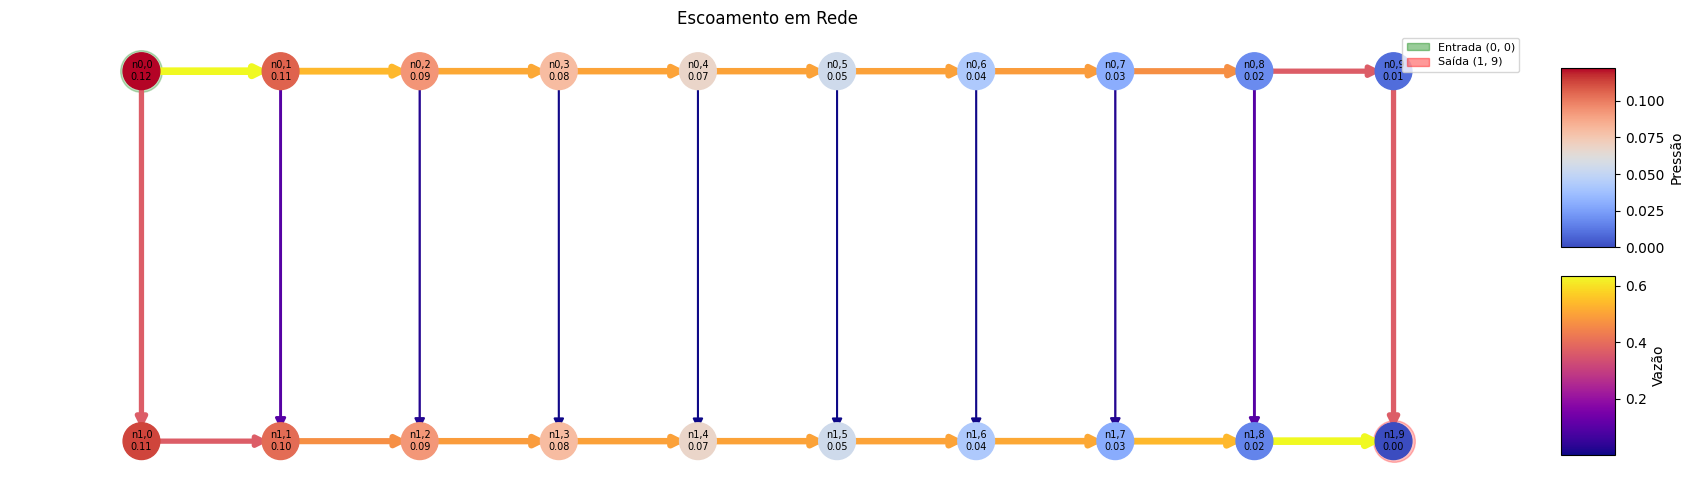

In [3]:
p1_20 = gerar_malha_retangular(
    n_linhas=2,
    n_colunas=10,
    area=1.0,
    length=1.0,
    mu=1e-3,
    patm=0.0,
    Q_in=1.0,
)

mostrar_resumo_p1(p1_20, "caso 1: malha retangular 2 x 10")

p1_20.plot_grid(
    show_node_labels=True,
    show_edge_labels=False,
)
plt.show()


In [4]:
p4_20, baseline_20, summary_20 = resolver_caso_p4(
    p1=p1_20,
    nome="caso 1: p4 com malha retangular 2 x 10",
    time_limit=30,
    mip_rel_gap=1e-4,
    disp=False,
    thick_pipe_fraction=0.10,
)


caso 1: p4 com malha retangular 2 x 10
numero de nos: 20
numero de arestas: 28
fracao de canos grossos: 0.1
numero de canos grossos: 3
status da solucao: otima
solucao otima certificada: True
mensagem do solver: Optimization terminated successfully. (HiGHS Status 7: Optimal)
gap mip: 0.0
reducao percentual da pressao maxima: 22.112310309234175 %
arestas grossas selecionadas: [('n0,0', 'n0,1'), ('n1,7', 'n1,8'), ('n1,8', 'n1,9')]


,caso,nos,arestas,canos_grossos,pressao_minima_pa,pressao_maxima_pa,amplitude_pressao_pa
0,todos finos,20,28,0,0.0,0.122297,0.122297
1,p4 otimizado,20,28,3,0.0,0.095254,0.095254


### 3.1. Arestas escolhidas no caso da malha `2 x 10`


In [5]:
edge_rows_20 = p4_20.edge_solution_table()

if pd is not None:
    edge_df_20 = pd.DataFrame(edge_rows_20)
    display(edge_df_20.sort_values(["x_grosso", "edge"], ascending=[False, True]))
else:
    for row in edge_rows_20:
        print(row)

,edge,tipo_cano,x_grosso,area_original,area_usada,length,condutancia_usada,delta_pressao,vazao
0,"(n0,0, n0,1)",grosso,1,1.0,2.0,1.0,159.154943,0.004985,0.793394
26,"(n1,7, n1,8)",grosso,1,1.0,2.0,1.0,159.154943,0.004655,0.740854
27,"(n1,8, n1,9)",grosso,1,1.0,2.0,1.0,159.154943,0.005299,0.843340
1,"(n0,0, n1,0)",fino,0,1.0,1.0,1.0,39.788736,0.005193,0.206606
2,"(n0,1, n0,2)",fino,0,1.0,1.0,1.0,39.788736,0.014540,0.578532
3,"(n0,1, n1,1)",fino,0,1.0,1.0,1.0,39.788736,0.005400,0.214862
4,"(n0,2, n0,3)",fino,0,1.0,1.0,1.0,39.788736,0.013087,0.520734
5,"(n0,2, n1,2)",fino,0,1.0,1.0,1.0,39.788736,0.001453,0.057798
6,"(n0,3, n0,4)",fino,0,1.0,1.0,1.0,39.788736,0.012677,0.504403
7,"(n0,3, n1,3)",fino,0,1.0,1.0,1.0,39.788736,0.000410,0.016331


### 3.2. Pressões nodais no caso da malha `2 x 10`


In [6]:
node_rows_20 = p4_20.node_solution_table()

if pd is not None:
    node_df_20 = pd.DataFrame(node_rows_20)
    display(node_df_20.sort_values("pressao", ascending=False))
else:
    for row in node_rows_20:
        print(row)

,node,pressao,fluxo_externo
0,"n0,0",0.095254,1.0
1,"n0,1",0.090269,0.0
10,"n1,0",0.090061,0.0
11,"n1,1",0.084869,0.0
2,"n0,2",0.075729,0.0
12,"n1,2",0.074276,0.0
3,"n0,3",0.062641,0.0
13,"n1,3",0.062231,0.0
4,"n0,4",0.049964,0.0
14,"n1,4",0.049775,0.0


### 3.3. Visualização da solução na malha `2 x 10`


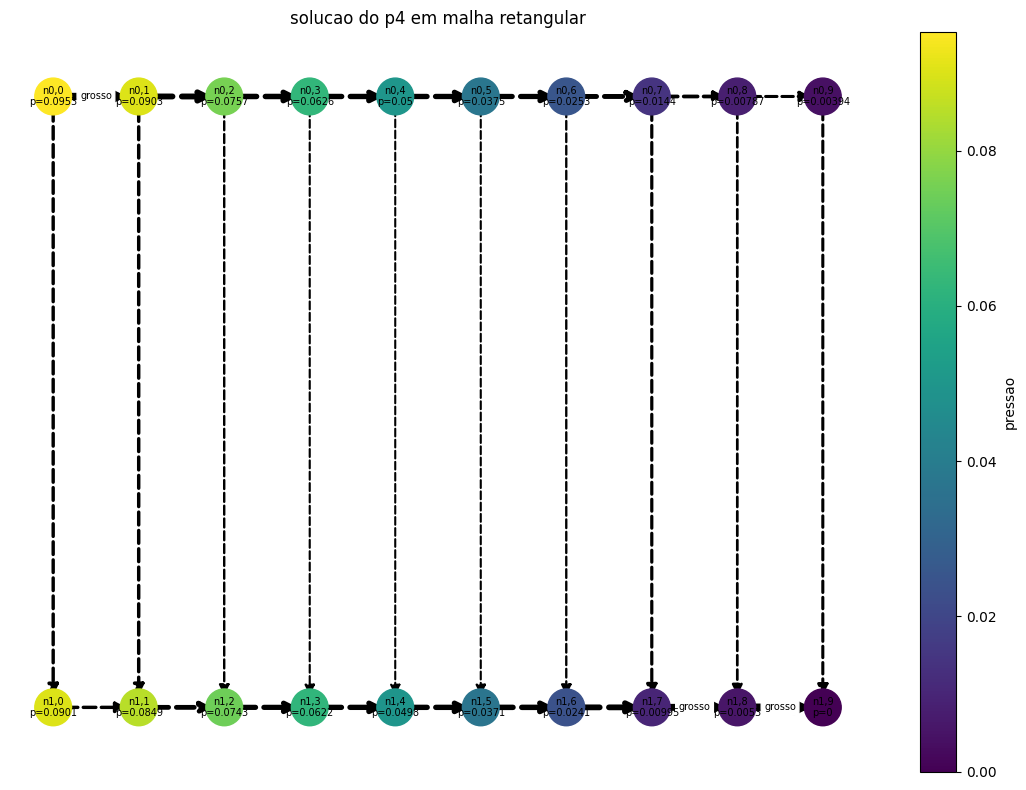

In [7]:
plotar_p4_malha_retangular(
    p4_20,
    figsize=(11, 8),
    show_node_labels=True,
    show_edge_labels=True,
)
plt.show()


## 4. Caso 2 — malha retangular `10 x 10`

Este caso usa uma malha retangular com 10 linhas e 10 colunas, totalizando 100 nós. A rede passa a ter uma estrutura regular, com conexões horizontais e verticais entre nós vizinhos. Isso mantém o problema maior, mas remove a aleatoriedade da geração do grafo.


caso 2: malha retangular 10 x 10
numero de nos: 100
numero de arestas: 180
pressao minima p1: 0.0 Pa
pressao maxima p1: 0.07569151184095146 Pa
amplitude de pressao p1: 0.07569151184095146 Pa


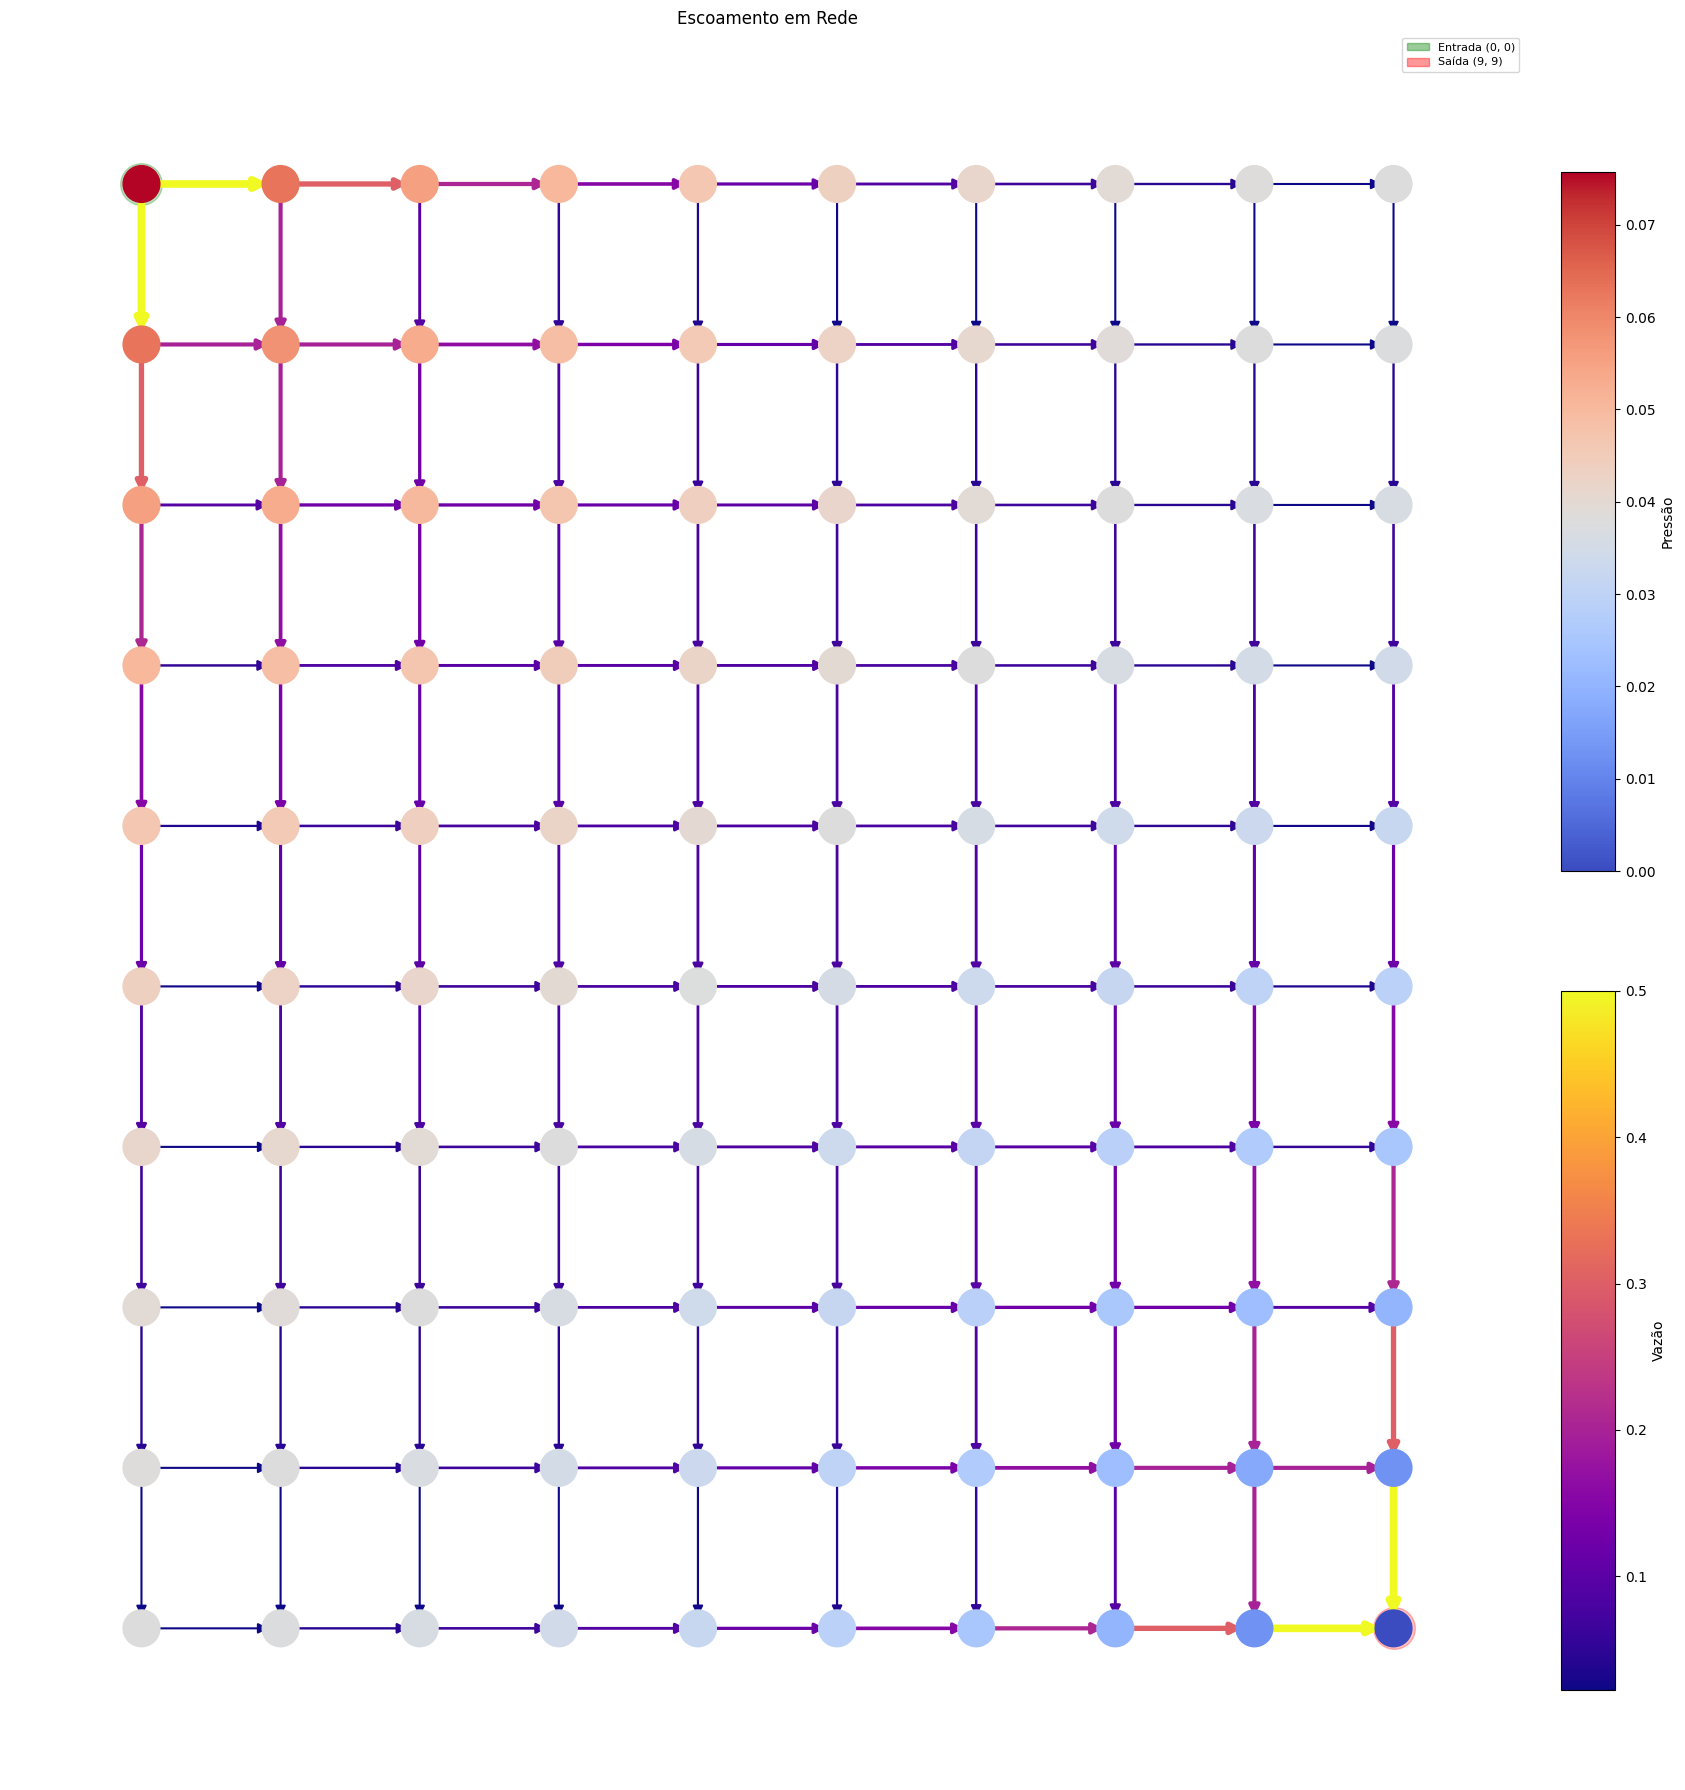

In [8]:
p1_100 = gerar_malha_retangular(
    n_linhas=10,
    n_colunas=10,
    area=1.0,
    length=1.0,
    mu=1e-3,
    patm=0.0,
    Q_in=1.0,
)

mostrar_resumo_p1(p1_100, "caso 2: malha retangular 10 x 10")

p1_100.plot_grid(
    show_node_labels=False,
    show_edge_labels=False,
)
plt.show()


In [17]:
p4_100, baseline_100, summary_100 = resolver_caso_p4(
    p1=p1_100,
    nome="caso 2: p4 com malha retangular 10 x 10",
    time_limit=3600,
    mip_rel_gap=1e-4,
    disp=False,
    thick_pipe_fraction=0.10,
)


caso 2: p4 com malha retangular 10 x 10
numero de nos: 100
numero de arestas: 180
fracao de canos grossos: 0.1
numero de canos grossos: 18
status da solucao: viavel_nao_certificada
solucao otima certificada: False
mensagem do solver: Time limit reached. (HiGHS Status 13: Time limit reached)
gap mip: 0.9071115876202724
reducao percentual da pressao maxima: 45.97402099060244 %
arestas grossas selecionadas: [('n0,0', 'n0,1'), ('n0,0', 'n1,0'), ('n0,1', 'n0,2'), ('n0,2', 'n0,3'), ('n1,0', 'n2,0'), ('n1,2', 'n1,3'), ('n1,3', 'n1,4'), ('n2,0', 'n3,0'), ('n5,7', 'n5,8'), ('n6,9', 'n7,9'), ('n7,9', 'n8,9'), ('n8,6', 'n8,7'), ('n8,7', 'n8,8'), ('n8,7', 'n9,7'), ('n8,8', 'n9,8'), ('n8,9', 'n9,9'), ('n9,7', 'n9,8'), ('n9,8', 'n9,9')]


,caso,nos,arestas,canos_grossos,pressao_minima_pa,pressao_maxima_pa,amplitude_pressao_pa
0,todos finos,100,180,0,0.0,0.075692,0.075692
1,p4 otimizado,100,180,18,0.0,0.040893,0.040893


### 4.1. Arestas escolhidas no caso da malha `10 x 10`


In [18]:
edge_rows_100 = p4_100.edge_solution_table()

if pd is not None:
    edge_df_100 = pd.DataFrame(edge_rows_100)
    display(edge_df_100.sort_values(["x_grosso", "edge"], ascending=[False, True]))
else:
    for row in edge_rows_100:
        print(row)

,edge,tipo_cano,x_grosso,area_original,area_usada,length,condutancia_usada,delta_pressao,vazao
0,"(n0,0, n0,1)",grosso,1,1.0,2.0,1.0,159.154943,0.003145,0.500479
1,"(n0,0, n1,0)",grosso,1,1.0,2.0,1.0,159.154943,0.003139,0.499521
2,"(n0,1, n0,2)",grosso,1,1.0,2.0,1.0,159.154943,0.002476,0.394005
4,"(n0,2, n0,3)",grosso,1,1.0,2.0,1.0,159.154943,0.001648,0.262325
20,"(n1,0, n2,0)",grosso,1,1.0,2.0,1.0,159.154943,0.002468,0.392808
...,...,...,...,...,...,...,...,...,...
173,"(n9,2, n9,3)",fino,0,1.0,1.0,1.0,39.788736,0.001650,0.065654
174,"(n9,3, n9,4)",fino,0,1.0,1.0,1.0,39.788736,0.002219,0.088296
175,"(n9,4, n9,5)",fino,0,1.0,1.0,1.0,39.788736,0.002816,0.112041
176,"(n9,5, n9,6)",fino,0,1.0,1.0,1.0,39.788736,0.003345,0.133083


### 4.2. Pressões nodais no caso da malha `10 x 10`


In [19]:
node_rows_100 = p4_100.node_solution_table()

if pd is not None:
    node_df_100 = pd.DataFrame(node_rows_100)
    display(node_df_100.sort_values("pressao", ascending=False))
else:
    for row in node_rows_100:
        print(row)

,node,pressao,fluxo_externo
0,"n0,0",0.040893,1.0
10,"n1,0",0.037754,0.0
1,"n0,1",0.037748,0.0
20,"n2,0",0.035286,0.0
2,"n0,2",0.035273,0.0
...,...,...,...
79,"n7,9",0.005249,0.0
88,"n8,8",0.004928,0.0
98,"n9,8",0.003403,0.0
89,"n8,9",0.002880,0.0


### 4.3. Visualização da solução na malha `10 x 10`


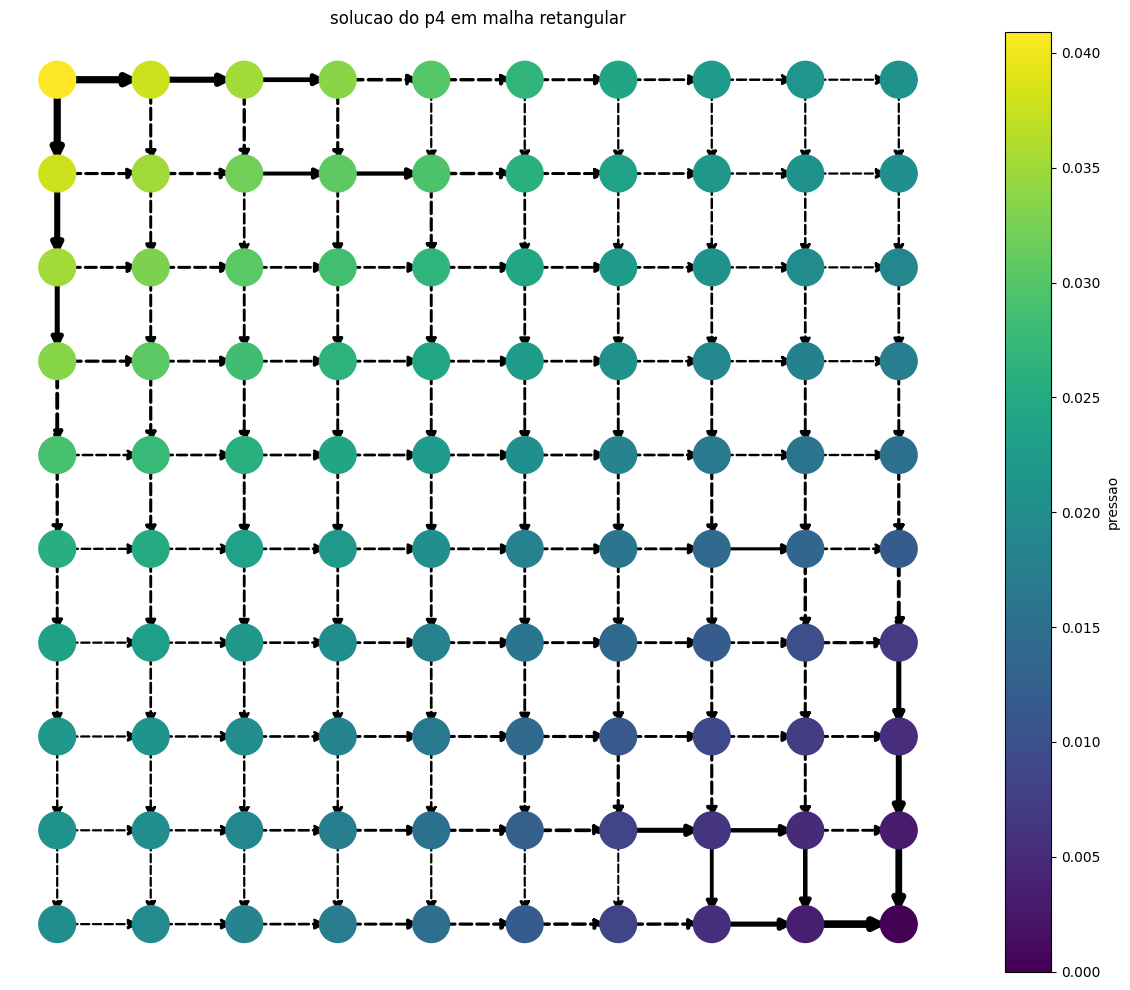

In [20]:
plotar_p4_malha_retangular(
    p4_100,
    figsize=(12, 10),
    show_node_labels=False,
    show_edge_labels=False,
)
plt.show()


## 5. Caso 3 — limite de tempo e retorno de solução não ótima

Este caso usa a mesma malha retangular `10 x 10` do caso 2. O limite de tempo é colocado artificialmente muito baixo. Com isso, o solver pode parar antes de certificar otimalidade. A implementação então segue a ordem:

1. usa a solução ótima, se ela foi certificada;
2. aceita a melhor solução inteira viável retornada pelo solver, se existir;
3. se o solver não retornar solução viável, usa uma heurística baseada nas maiores quedas de pressão da rede com todos os canos finos.

O objetivo deste caso não é produzir o melhor resultado possível, mas mostrar que o notebook continua retornando uma configuração admissível em uma malha retangular.


In [21]:
p4_timeout, baseline_timeout, summary_timeout = resolver_caso_p4(
    p1=p1_100,
    nome="caso 3: malha retangular 10 x 10 com limite de tempo artificialmente baixo",
    time_limit=1e-9,
    mip_rel_gap=1e-4,
    disp=False,
)

caso 3: malha retangular 10 x 10 com limite de tempo artificialmente baixo
numero de nos: 100
numero de arestas: 180
fracao de canos grossos: 0.1
numero de canos grossos: 18
status da solucao: heuristica
solucao otima certificada: False
mensagem do solver: Time limit reached. (HiGHS Status 13: model_status is Time limit reached; primal_status is At lower/fixed bound)
gap mip: None
reducao percentual da pressao maxima: 46.42392397729678 %
arestas grossas selecionadas: [('n0,0', 'n0,1'), ('n0,0', 'n1,0'), ('n0,1', 'n0,2'), ('n0,2', 'n0,3'), ('n1,0', 'n1,1'), ('n1,0', 'n2,0'), ('n1,1', 'n2,1'), ('n2,0', 'n3,0'), ('n6,9', 'n7,9'), ('n7,8', 'n8,8'), ('n7,9', 'n8,9'), ('n8,7', 'n8,8'), ('n8,8', 'n8,9'), ('n8,8', 'n9,8'), ('n8,9', 'n9,9'), ('n9,6', 'n9,7'), ('n9,7', 'n9,8'), ('n9,8', 'n9,9')]


,caso,nos,arestas,canos_grossos,pressao_minima_pa,pressao_maxima_pa,amplitude_pressao_pa
0,todos finos,100,180,0,0.0,0.075692,0.075692
1,p4 otimizado,100,180,18,0.0,0.040553,0.040553


### 5.1. Interpretação do status

A chave `solution_status` resume o tipo de solução retornada:

- `otima`: o solver certificou otimalidade global;
- `viavel_nao_certificada`: o solver parou antes da certificação, mas retornou uma solução inteira viável;
- `heuristica`: o solver não retornou solução inteira viável aproveitável e foi usada a heurística de fallback.

In [22]:
summary_timeout

{'objective_pressure_max': 0.04055254192664157,
 'solver_objective': 0.04055254192664157,
 'pressure_min': 0.0,
 'pressure_max': 0.04055254192664157,
 'pressure_range': 0.04055254192664157,
 'objective_pressure_range': 0.04055254192664157,
 'max_thick_pipes': 18,
 'n_thick_used': 18,
 'selected_thick_edges': [('n0,0', 'n0,1'),
  ('n0,0', 'n1,0'),
  ('n0,1', 'n0,2'),
  ('n0,2', 'n0,3'),
  ('n1,0', 'n1,1'),
  ('n1,0', 'n2,0'),
  ('n1,1', 'n2,1'),
  ('n2,0', 'n3,0'),
  ('n6,9', 'n7,9'),
  ('n7,8', 'n8,8'),
  ('n7,9', 'n8,9'),
  ('n8,7', 'n8,8'),
  ('n8,8', 'n8,9'),
  ('n8,8', 'n9,8'),
  ('n8,9', 'n9,9'),
  ('n9,6', 'n9,7'),
  ('n9,7', 'n9,8'),
  ('n9,8', 'n9,9')],
 'solution_status': 'heuristica',
 'solution_is_optimal': False,
 'solver_message': 'Time limit reached. (HiGHS Status 13: model_status is Time limit reached; primal_status is At lower/fixed bound)',
 'mip_gap': None}

### 5.2. Arestas escolhidas no caso com limite de tempo

In [23]:
edge_rows_timeout = p4_timeout.edge_solution_table()

if pd is not None:
    edge_df_timeout = pd.DataFrame(edge_rows_timeout)
    display(edge_df_timeout.sort_values(["x_grosso", "edge"], ascending=[False, True]))
else:
    for row in edge_rows_timeout:
        print(row)

,edge,tipo_cano,x_grosso,area_original,area_usada,length,condutancia_usada,delta_pressao,vazao
0,"(n0,0, n0,1)",grosso,1,1.0,2.0,1.0,159.154943,0.002865,0.455920
1,"(n0,0, n1,0)",grosso,1,1.0,2.0,1.0,159.154943,0.003419,0.544080
2,"(n0,1, n0,2)",grosso,1,1.0,2.0,1.0,159.154943,0.002358,0.375267
4,"(n0,2, n0,3)",grosso,1,1.0,2.0,1.0,159.154943,0.001830,0.291309
19,"(n1,0, n1,1)",grosso,1,1.0,2.0,1.0,159.154943,0.001473,0.234451
...,...,...,...,...,...,...,...,...,...
172,"(n9,1, n9,2)",fino,0,1.0,1.0,1.0,39.788736,0.001144,0.045514
173,"(n9,2, n9,3)",fino,0,1.0,1.0,1.0,39.788736,0.001728,0.068747
174,"(n9,3, n9,4)",fino,0,1.0,1.0,1.0,39.788736,0.002366,0.094145
175,"(n9,4, n9,5)",fino,0,1.0,1.0,1.0,39.788736,0.003158,0.125648


### 5.3. Visualização da solução retornada no caso com limite de tempo


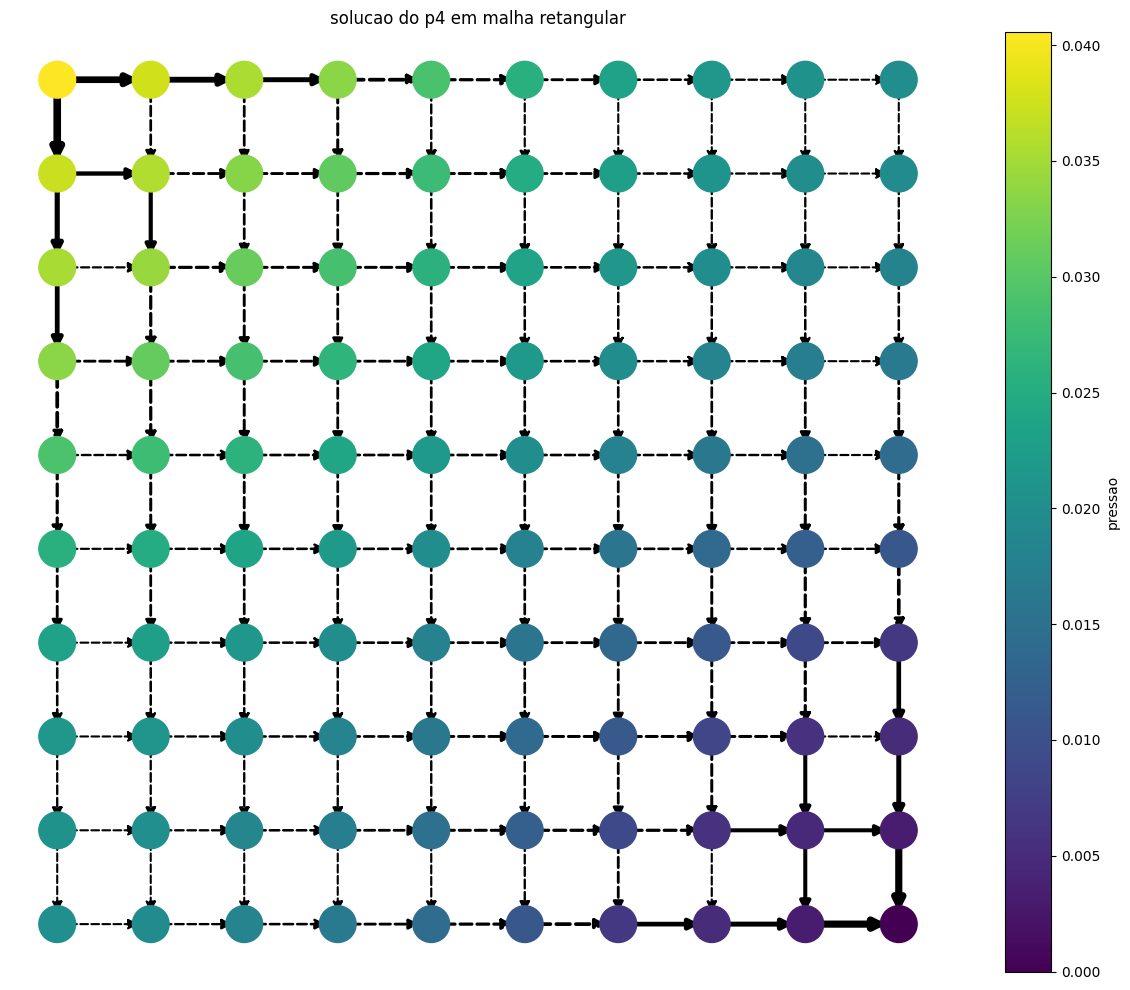

In [24]:
plotar_p4_malha_retangular(
    p4_timeout,
    figsize=(12, 10),
    show_node_labels=False,
    show_edge_labels=False,
)
plt.show()
